In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("AEP_hourly.csv")
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [3]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

**Baseline Forecasting Method**

In [5]:
df['Naive_Forecast'] = df['AEP_MW'].shift(1)

In [6]:
df.dropna(inplace=True)

In [7]:
df['lag_1'] = df['AEP_MW'].shift(1)
df['lag_24'] = df['AEP_MW'].shift(24)
df['lag_168'] = df['AEP_MW'].shift(168)

In [8]:
df['rolling_mean_24'] = df['AEP_MW'].rolling(window=24).mean()
df['rolling_std_24'] = df['AEP_MW'].rolling(window=24).std()

In [9]:
df['hour'] = df['Datetime'].dt.hour
df['dayofweek'] = df['Datetime'].dt.dayofweek
df['month'] = df['Datetime'].dt.month

In [10]:
df.dropna(inplace=True)

**Train Test Split**

In [11]:
train = df[df['Datetime'] < '2018-01-01']
test = df[df['Datetime'] >= '2018-01-01']

In [12]:
features = [
    'lag_1',
    'lag_24',
    'lag_168',
    'rolling_mean_24',
    'rolling_std_24',
    'hour',
    'dayofweek',
    'month'
]

target = 'AEP_MW'

**XGBoost Model**

In [13]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42
)

model.fit(train[features], train[target])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [14]:
test['XGB_Predictions'] = model.predict(test[features])

Evaluation Metrics

In [15]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


Naive Forecast evaluation

In [16]:
mae_naive = mean_absolute_error(test[target], test['Naive_Forecast'])
rmse_naive = np.sqrt(mean_squared_error(test[target], test['Naive_Forecast']))
mape_naive = mape(test[target], test['Naive_Forecast'])

XGBoost evaluation

In [17]:
mae_xgb = mean_absolute_error(test[target], test['XGB_Predictions'])
rmse_xgb = np.sqrt(mean_squared_error(test[target], test['XGB_Predictions']))
mape_xgb = mape(test[target], test['XGB_Predictions'])

Comparison between the two

In [18]:
comparison = pd.DataFrame({
    'Model': ['Naive Forecast', 'XGBoost'],
    'MAE': [mae_naive, mae_xgb],
    'RMSE': [rmse_naive, rmse_xgb],
    'MAPE': [mape_naive, mape_xgb]
})

comparison

,Model,MAE,RMSE,MAPE
0,Naive Forecast,415.096184,525.058464,2.765106
1,XGBoost,128.595719,170.634026,0.837484


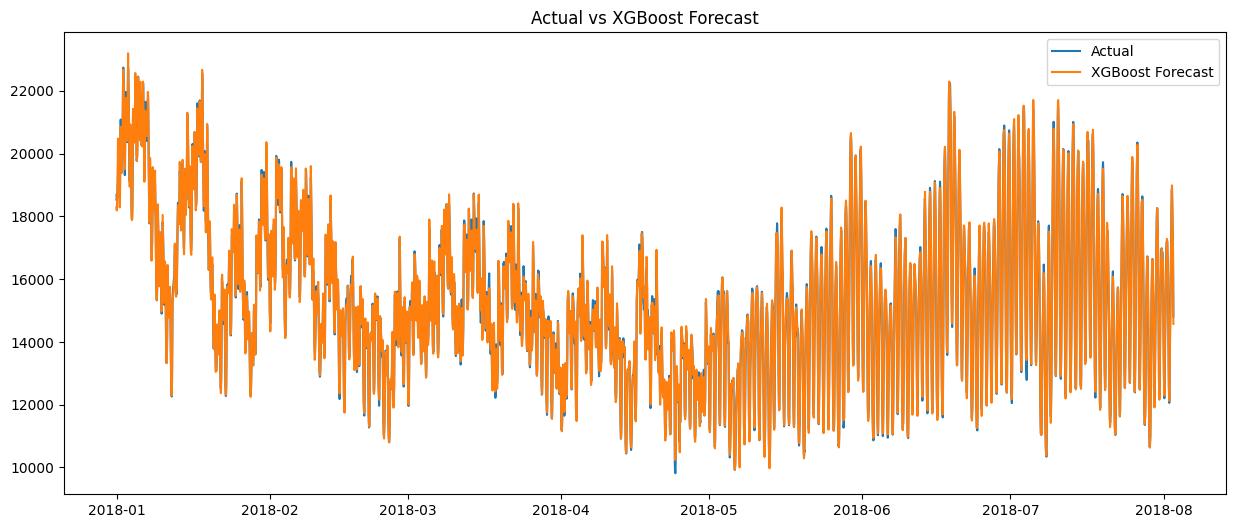

In [19]:
plt.figure(figsize=(15,6))
plt.plot(test['Datetime'], test[target], label='Actual')
plt.plot(test['Datetime'], test['XGB_Predictions'], label='XGBoost Forecast')
plt.legend()
plt.title("Actual vs XGBoost Forecast")
plt.show()

Reflection

1. XGBoost significantly improved forecasting accuracy
2. Time-based validation is essential
3. Proper lag selection improves performance

Strengths

1. Captures complex non-linear patterns
2. Handles lag features very well
3. Better than baseline forecast

Weaknesses

1. Requires feature engineering
2. More computationally expensive
3. Harder to interpret than baseline

